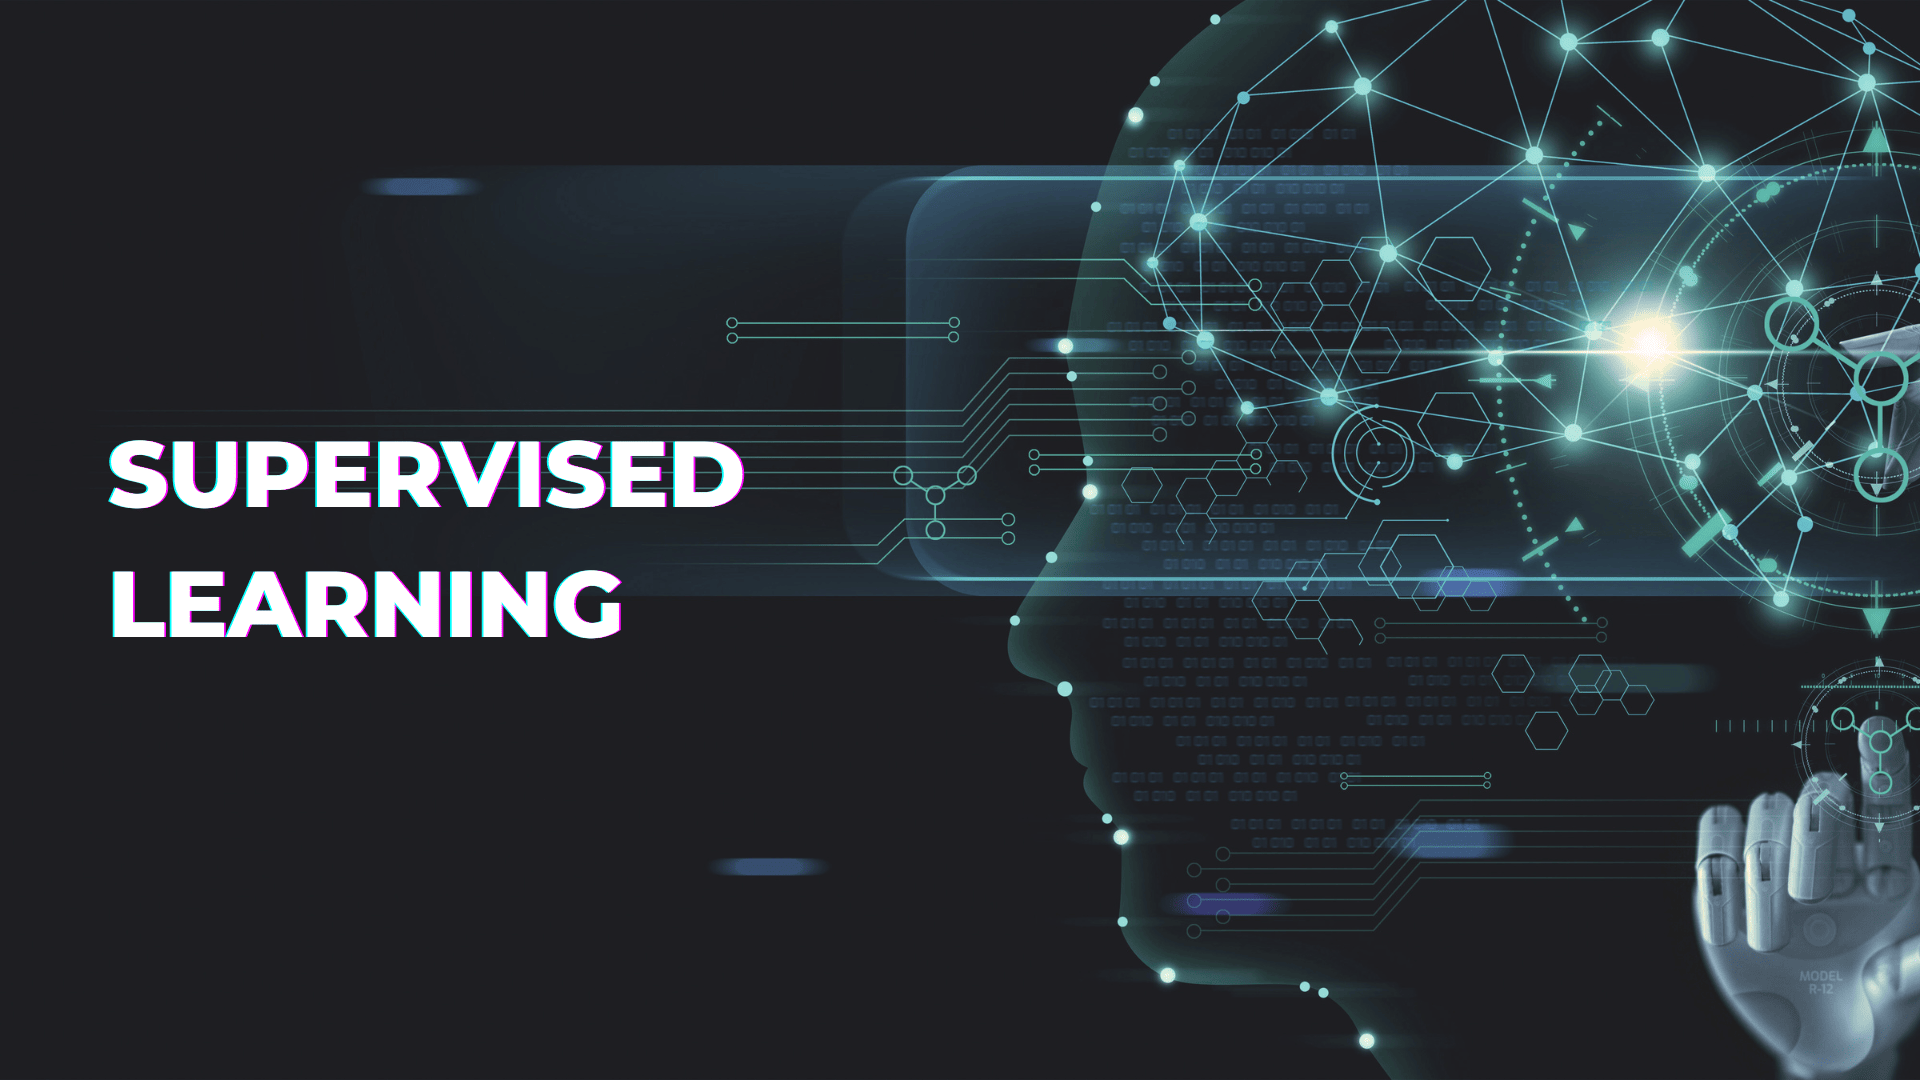

# **SUPERVISED LEARNING CASE STUDIES**

## **Objectives**

- To implement and understand different supervised machine learning classification algorithms.
- To preprocess data and prepare it for model training and testing.
- To train and evaluate KNN, Decision Tree, Random Forest, and SVM models.
- To measure and compare model performance using suitable evaluation metrics.
- To identify the best-performing model for a given prediction problem.

In [69]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Import preprocessing and data splitting tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Ignore warning messages
warnings.filterwarnings("ignore")

## **1. KNN - Student Pass Prediction Case Study**

**Objective:**  
To predict whether a student will pass or fail based on study hours and attendance percentage using the K-Nearest Neighbors algorithm.

In [2]:
# Create dataset
student_data = {
    "StudyHours": [2,3,4,5,6,7,8,1,2,9],
    "Attendance": [50,55,60,65,70,75,80,40,45,90],
    "Pass": [0,0,0,1,1,1,1,0,0,1]
}

stu_df = pd.DataFrame(student_data)
stu_df

,StudyHours,Attendance,Pass
0,2,50,0
1,3,55,0
2,4,60,0
3,5,65,1
4,6,70,1
5,7,75,1
6,8,80,1
7,1,40,0
8,2,45,0
9,9,90,1


In [3]:
# Features and Target
X = stu_df[["StudyHours", "Attendance"]]
y = stu_df["Pass"]

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Train KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
# Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [8]:
# Make prediction
prediction = model.predict(
    scaler.transform([[5, 70]])
)

# Print the actual input with names
print("Input:")
print("Study Hours:", 5)
print("Attendance:", 70)

# Print the prediction
print("\nPrediction:", "Pass" if prediction[0] == 1 else "Fail")

Input:
Study Hours: 5
Attendance: 70

Prediction: Pass


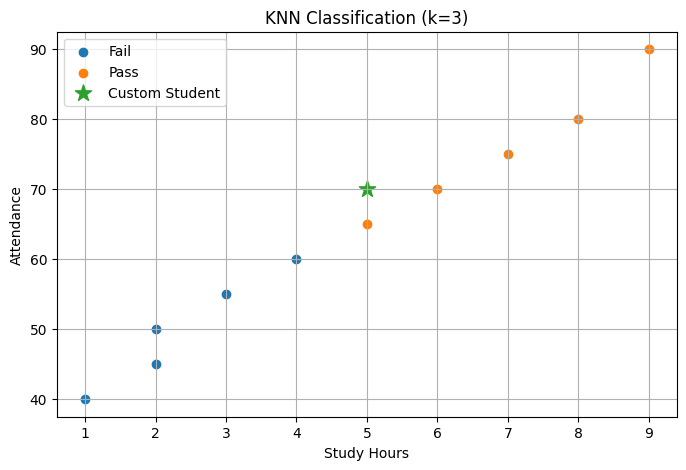

In [46]:
# Plot data
plt.figure(figsize=(8, 5))

for label in [0, 1]:
    data = stu_df[stu_df["Pass"] == label]
    plt.scatter(
        data["StudyHours"],
        data["Attendance"],
        label="Fail" if label == 0 else "Pass"
    )

# Plot custom student
plt.scatter(
    5, 70,
    marker="*",
    s=150,
    label="Custom Student"
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("KNN Classification (k=3)")
plt.legend()
plt.grid()
plt.show()

## **2. Decision Tree - Loan Approval Prediction Case Study**

**Objective:**  
To predict whether a loan application will be approved based on the applicant's income and credit score using a Decision Tree model.

In [54]:
# Create dataset
loan_data = {
    "Income": [25000,30000,40000,50000,60000,70000,80000,90000],
    "CreditScore": [500,550,600,650,700,750,780,800],
    "Approved": [0,0,0,1,1,1,1,1]
}

loan_df = pd.DataFrame(loan_data)
loan_df

,Income,CreditScore,Approved
0,25000,500,0
1,30000,550,0
2,40000,600,0
3,50000,650,1
4,60000,700,1
5,70000,750,1
6,80000,780,1
7,90000,800,1


In [55]:
# Features and Target
X = loan_df[["Income", "CreditScore"]]
y = loan_df["Approved"]

In [56]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

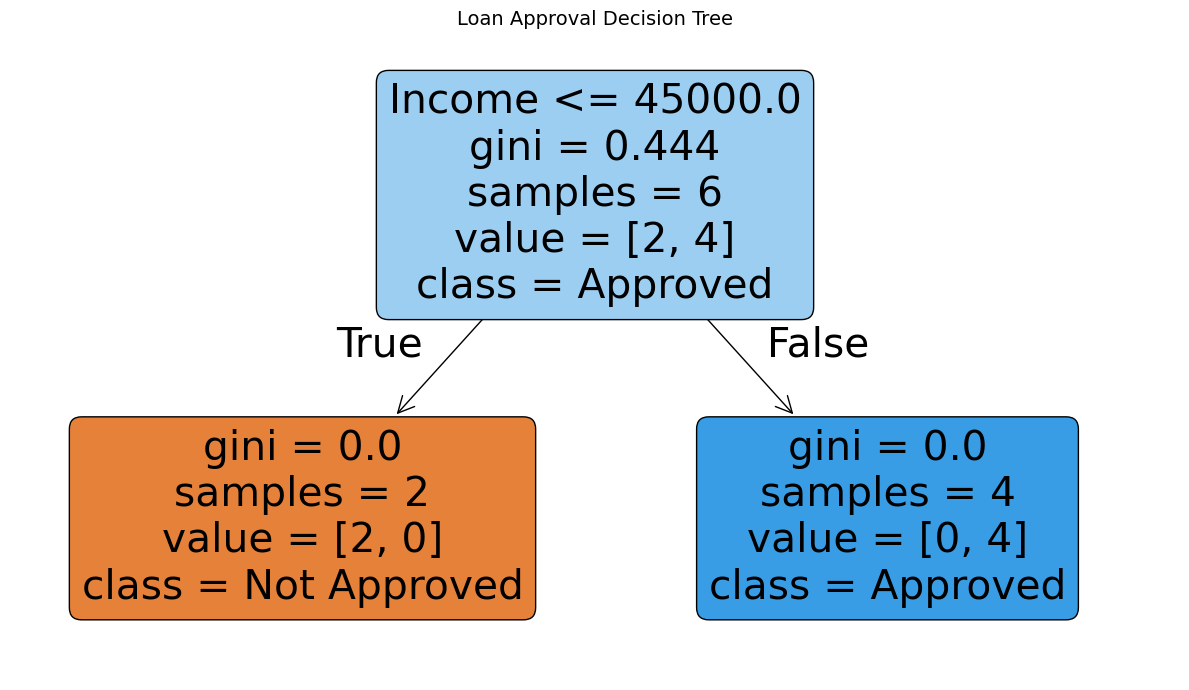

In [59]:
# Plot the Decision Tree
plt.figure(figsize=(12, 7))

plot_tree(
    model,
    filled=True,
    rounded=True,
    feature_names=["Income", "CreditScore"],
    class_names=["Not Approved", "Approved"]
)

plt.title("Loan Approval Decision Tree", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [17]:
# Make prediction
prediction = model.predict([[65000, 720]])

# Print the actual input with names
print("Input:")
print("Income:", 65000)
print("Credit Score:", 720)

# Print the prediction
print("\nPrediction:", "Approved" if prediction[0] == 1 else "Rejected")

Input:
Income: 65000
Credit Score: 720

Prediction: Approved


## **3. Random Forest - Employee Promotion Prediction Case Study**

**Objective:**  
To predict whether an employee will be promoted based on experience and performance score using a Random Forest classifier.

In [19]:
# Create dataset
emp_data = {
    "Experience": [1,2,3,4,5,6,7,8,9,10],
    "Performance": [50,55,60,65,70,75,80,85,90,95],
    "Promoted": [0,0,0,0,1,1,1,1,1,1]
}

emp_df = pd.DataFrame(emp_data)
emp_df

,Experience,Performance,Promoted
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,0
4,5,70,1
5,6,75,1
6,7,80,1
7,8,85,1
8,9,90,1
9,10,95,1


In [20]:
# Feature and Target
X = emp_df[["Experience", "Performance"]]
y = emp_df["Promoted"]

In [21]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
# Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [24]:
# Make prediction
prediction = model.predict([[6, 78]])

# Print the actual input with names
print("Input:")
print("Experience:", 6)
print("Performance:", 78)

# Print the prediction
print("\nPrediction:", "Promoted" if prediction[0] == 1 else "Not Promoted")

Input:
Experience: 6
Performance: 78

Prediction: Promoted


## **4. SVM - Customer Purchase Prediction Case Study**

**Objective:**  
To predict whether a customer will purchase a product based on age and salary using a Support Vector Machine classifier.

In [62]:
# Create dataset
cust_data = {
    "Age": [20,22,25,28,30,35,40,45,50,55],
    "Salary": [20000,25000,30000,35000,40000,50000,60000,70000,80000,90000],
    "Buy": [0,0,0,0,1,1,1,1,1,1]
}

cust_df = pd.DataFrame(cust_data)
cust_df

,Age,Salary,Buy
0,20,20000,0
1,22,25000,0
2,25,30000,0
3,28,35000,0
4,30,40000,1
5,35,50000,1
6,40,60000,1
7,45,70000,1
8,50,80000,1
9,55,90000,1


In [63]:
# Feature and Target
X = cust_df[["Age", "Salary"]]
y = cust_df["Buy"]

In [64]:
# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [65]:
# Train SVM
model = SVC(kernel="linear")
model.fit(X_train, y_train)

SVC(kernel='linear')

In [66]:
# Evaluate model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [67]:
# Make prediction
prediction = model.predict(
    scaler.transform([[32, 45000]])
)

# Print the actual input with names
print("Input:")
print("Age:", 32)
print("Salary:", 45000)

# Print the prediction
print("\nPrediction:", "Buy" if prediction[0] == 1 else "Not Buy")

Input:
Age: 32
Salary: 45000

Prediction: Buy


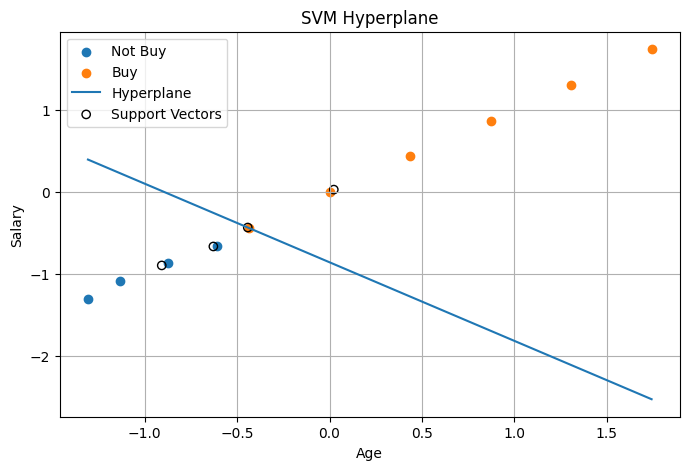

In [71]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], label="Not Buy")
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], label="Buy")

# Hyperplane
w = model.coef_[0]
b = model.intercept_[0]

x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y_line = -(w[0] * x + b) / w[1]

plt.plot(x, y_line, label="Hyperplane")

# Support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("SVM Hyperplane")
plt.legend()
plt.grid()
plt.show()

## **5. Mini Project - Titanic Survival Prediction Case Study**

**Objective:**  
To compare KNN, Decision Tree, Random Forest, and SVM models for predicting Titanic passenger survival using accuracy, precision, recall, and F1-score, and identify the best-performing model.

In [32]:
# Load and prepare dataset
path = r"/content/Titanic Dataset.csv"
titanic_df = pd.read_csv(path)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
# Info about the data
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [34]:
# Statistical summary
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
# Drop useless columns
titanic_df = titanic_df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Find missing values
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [36]:
# Fill the missing values
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

In [37]:
# Column types
cat_cols = ["Sex", "Embarked", "Pclass"]
num_cols = ["Age", "SibSp", "Parch", "Fare"]

# One-hot encode categorical variables and drop first category
encoder = OneHotEncoder(sparse_output=False, drop="first")
encoded_cols = encoder.fit_transform(titanic_df[cat_cols])

encoded_df = pd.DataFrame(
    encoded_cols,
    columns=encoder.get_feature_names_out(cat_cols),
    index=titanic_df.index
)

# Concatenate numerical and encoded columns
X = pd.concat([titanic_df[num_cols], encoded_df], axis=1)
y = titanic_df["Survived"]

X.head()

,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,22.0,1,0,7.2500,1.0,0.0,1.0,0.0,1.0
1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0,0.0
2,26.0,0,0,7.9250,0.0,0.0,1.0,0.0,1.0
3,35.0,1,0,53.1000,0.0,0.0,1.0,0.0,0.0
4,35.0,0,0,8.0500,1.0,0.0,1.0,0.0,1.0


In [38]:
# Train test split and scaled
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# Decision Tree Model
dt = DecisionTreeClassifier(max_depth=6, random_state=1)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=250, random_state=1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# SVM Model
svm = SVC(kernel="rbf", C=1.0, random_state=1)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

In [40]:
def scores(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

comparison = pd.DataFrame(
    [
        scores(y_test, knn_pred),
        scores(y_test, dt_pred),
        scores(y_test, rf_pred),
        scores(y_test, svm_pred)
    ],
    columns=["Accuracy", "Precision", "Recall", "F1 Score"],
    index=["KNN", "Decision Tree", "Random Forest", "SVM"]
)

comparison.round(4)

,Accuracy,Precision,Recall,F1 Score
KNN,0.8045,0.7656,0.7101,0.7368
Decision Tree,0.7821,0.7344,0.6812,0.7068
Random Forest,0.8268,0.7714,0.7826,0.7770
SVM,0.8492,0.8889,0.6957,0.7805


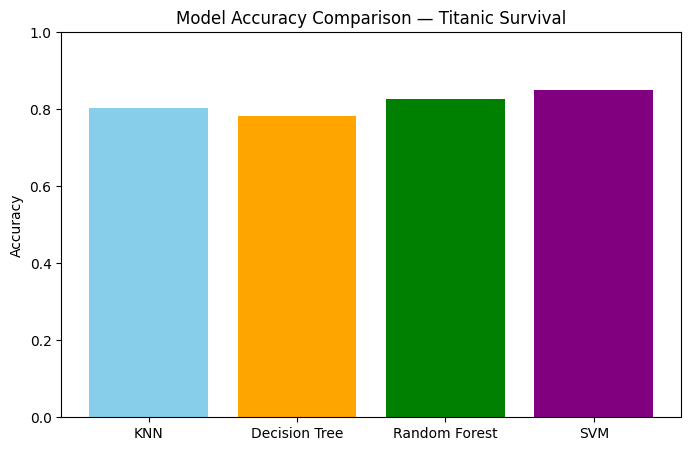


Best performing model: SVM
Accuracy     0.849162
Precision    0.888889
Recall       0.695652
F1 Score     0.780488
Name: SVM, dtype: float64


In [72]:
# Model graph comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison.index,
    comparison["Accuracy"],
    color=["skyblue", "orange", "green", "purple"]
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison — Titanic Survival")
plt.show()

best_model = comparison["Accuracy"].idxmax()

print("\nBest performing model:", best_model)
print(comparison.loc[best_model])

In [73]:
# Models
models = {
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm
}

model = models[best_model]

In [43]:
# Predict custom data
sample_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [28],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [90],
    "Embarked": ["S"]
})

sample_cat = encoder.transform(sample_passenger[cat_cols])

sample_cat_df = pd.DataFrame(
    sample_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

sample_X = pd.concat(
    [
        sample_passenger[num_cols].reset_index(drop=True),
        sample_cat_df.reset_index(drop=True)
    ],
    axis=1
)

if best_model in ["KNN", "SVM"]:
    sample_X = scaler.transform(sample_X)

sample_pred = rf.predict(sample_X)

# Input with names
print("Input:")
print("Pclass:", 1)
print("Sex:", "female")
print("Age:", 28)
print("SibSp:", 0)
print("Parch:", 0)
print("Fare:", 90)
print("Embarked:", "S")

# Prediction
print("\nPrediction:", "Survived" if sample_pred[0] == 1 else "Did not survive")

Input:
Pclass: 1
Sex: female
Age: 28
SibSp: 0
Parch: 0
Fare: 90
Embarked: S

Prediction: Survived


### **Conclusion**

- Among the four models, **SVM achieved the best overall performance**, obtaining the highest accuracy and precision.
- **Random Forest** performed well in terms of recall and F1-score, making it a strong alternative.
- **KNN** provided competitive results after feature scaling, while **Decision Tree** showed comparatively lower performance.
- Overall, **SVM and Random Forest** were the most effective models for predicting Titanic survival based on the evaluation metrics.

*These ML models also help understand patterns in the data and evaluate how different factors can impact business decisions, enabling organizations to make more informed and data-driven decisions.*

---
### **Completed By:** *Monish D.Y. - 230701195*